# Ensemble voting — VietOCR + PaddleOCR + TrOCR

Ba model nhận dạng cùng một tập `rec_test.txt`, hợp phiếu theo hai cách và so với từng model đơn lẻ.

Luật hợp phiếu: hai model bất kỳ trùng nhau thì lấy kết quả đó, cả ba khác nhau thì lấy VietOCR.
Đo song song *mức dòng* (so nguyên chuỗi) và *mức ký tự* (ROVER — căn chỉnh ba chuỗi rồi bỏ phiếu
từng vị trí, hoà thì theo VietOCR).

## 1. Cấu hình

In [1]:
import time
SESSION_START = time.time()

SEED         = 2026
IGNORE_SPACE = True
LIMIT        = None

DATA_DIR  = "/kaggle/input/datasets/quachthanhhmd/dack-nlp/DACK/data/vi_rec_100k/vi_rec_100k"
TEST_FILE = "/kaggle/input/datasets/quachthanhhmd/dack-nlp/DACK/data/vi_rec_100k/vi_rec_100k/rec_test.txt"
DICT_FILE = "/kaggle/input/datasets/quachthanhhmd/dack-nlp/DACK/data/vi_dict.txt"

TRAIN_FILE = "/kaggle/input/datasets/quachthanhhmd/dack-nlp/DACK/data/vi_rec_100k/vi_rec_100k/rec_train.txt"

VIETOCR_CKPT = "/kaggle/input/models/quachthanhhmd/viet-ocr-fintune/pytorch/default/4/vietocr_finetune/vietocr_finetune"
VIETOCR_YAML = '/kaggle/input/models/quachthanhhmd/viet-ocr-fintune/pytorch/default/4/finetune.yaml'
PADDLE_CKPT  = "/kaggle/input/models/quachthanhhmd/paddleocr-custom-det/other/default/1"
TROCR_CKPT   = "/kaggle/input/models/quachthanhhmd/trocr-model/other/default/1/trocr_model"

VIETOCR_BATCH = 16
TROCR_BATCH   = 24

PRIORITY = ["VietOCR", "PaddleOCR", "TrOCR"]

VIETOCR_VOCAB = 'aAàÀảẢãÃáÁạẠăĂằẰẳẲẵẴắẮặẶâÂầẦẩẨẫẪấẤậẬbBcCdDđĐeEèÈẻẺẽẼéÉẹẸêÊềỀểỂễỄếẾệỆfFgGhHiIìÌỉỈĩĨíÍịỊjJkKlLmMnNoOòÒỏỎõÕóÓọỌôÔồỒổỔỗỖốỐộỘơƠờỜởỞỡỠớỚợỢpPqQrRsStTuUùÙủỦũŨúÚụỤưƯừỪửỬữỮứỨựỰvVwWxXyYỳỲỷỶỹỸýÝỵỴzZ0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~ «²¹»äçüāēěīōūǎǒǔ–—’“”•…'

VIETOCR_CFG = {
    "vocab": VIETOCR_VOCAB,
    "backbone": "vgg19_bn", "seq_modeling": "transformer",
    "cnn": {"pretrained": False, "hidden": 256,
            "ss": [[2, 2], [2, 2], [2, 1], [2, 1], [2, 1]],
            "ks": [[2, 2], [2, 2], [2, 1], [2, 1], [2, 1]]},
    "transformer": {"d_model": 256, "nhead": 8, "num_encoder_layers": 6,
                    "num_decoder_layers": 6, "dim_feedforward": 2048,
                    "max_seq_length": 1024, "pos_dropout": 0.1, "trans_dropout": 0.1},
    "dataset": {"image_height": 64, "image_min_width": 32, "image_max_width": 1024},
    "predictor": {"beamsearch": False}, "quiet": True,
}


def hms(s):
    s = int(s)
    return f"{s//3600}h{(s%3600)//60:02d}m{s%60:02d}s"


def elapsed():
    return hms(time.time() - SESSION_START)

## 2. Môi trường

In [2]:
import subprocess, sys, os, gc, importlib
from pathlib import Path


def sh(cmd, check=True, quiet=True, cwd=None):
    p = subprocess.run(cmd, shell=isinstance(cmd, str), capture_output=True, text=True,
                       cwd=str(cwd) if cwd else None)
    if check and p.returncode != 0:
        print(p.stdout[-1500:]); print(p.stderr[-1500:])
        raise RuntimeError(f"that bai: {cmd}")
    if not quiet and p.stdout.strip():
        print(p.stdout.strip()[-600:])
    return p


for mod, pkg in [("rapidfuzz", "rapidfuzz"), ("vietocr", "vietocr"),
                 ("einops", "einops"), ("yaml", "pyyaml")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        sh([sys.executable, "-m", "pip", "install", "-q",
            *(["--no-deps"] if pkg == "vietocr" else []), pkg])

import torch, transformers

assert torch.cuda.is_available(), "Bat Accelerator GPU"
GPUS   = [f"cuda:{i}" for i in range(torch.cuda.device_count())]
DEVICE = GPUS[0]

print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
for i, g in enumerate(GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f"{g:<12}: {p.name}  {p.total_memory/1e9:.0f} GB")

torch       : 2.10.0+cu128
transformers: 5.0.0
cuda:0      : Tesla T4  16 GB
cuda:1      : Tesla T4  16 GB


## 3. Dữ liệu và checkpoint

In [3]:
import json, zipfile

WORK        = Path("/kaggle/working/vote")
SCRATCH     = Path("/kaggle/temp")
RESULTS_DIR = WORK / "results"
for p in (WORK, SCRATCH, RESULTS_DIR):
    p.mkdir(parents=True, exist_ok=True)

DATA_DIR     = Path(DATA_DIR)
TEST_FILE    = Path(TEST_FILE)
DICT_FILE    = Path(DICT_FILE)
VIETOCR_PATH = Path(VIETOCR_CKPT)
PADDLE_PATH  = Path(PADDLE_CKPT)
TROCR_PATH   = Path(TROCR_CKPT)

for label, p in [("anh", DATA_DIR), ("rec_test", TEST_FILE), ("vi_dict", DICT_FILE),
                 ("VietOCR", VIETOCR_PATH), ("PaddleOCR", PADDLE_PATH), ("TrOCR", TROCR_PATH)]:
    assert p.exists(), f"{label}: khong ton tai {p}"
    print(f"{label:<10} {p}")

assert (TROCR_PATH / "config.json").exists(), (
    f"TrOCR: khong thay config.json trong {TROCR_PATH}\n  thu muc dang chua: "
    + (str(sorted(f.name for f in TROCR_PATH.iterdir())[:15]) if TROCR_PATH.is_dir()
       else "day la mot file, khong phai thu muc model da xuat"))

with open(TEST_FILE, encoding="utf-8") as f:
    first = os.path.normpath(next(l for l in f if l.strip()).split("\t", 1)[0])
assert (DATA_DIR / first).exists(), (
    f"rec_test.txt tro toi {first} nhung {DATA_DIR / first} khong ton tai — "
    "DATA_DIR phai la thu muc goc ma duong dan trong rec_test.txt tinh tuong doi tu do")
print("\ntest      ", sum(1 for _ in TEST_FILE.open(encoding="utf-8")), "dong")

anh        /kaggle/input/datasets/quachthanhhmd/dack-nlp/DACK/data/vi_rec_100k/vi_rec_100k
rec_test   /kaggle/input/datasets/quachthanhhmd/dack-nlp/DACK/data/vi_rec_100k/vi_rec_100k/rec_test.txt
vi_dict    /kaggle/input/datasets/quachthanhhmd/dack-nlp/DACK/data/vi_dict.txt
VietOCR    /kaggle/input/models/quachthanhhmd/viet-ocr-fintune/pytorch/default/4/vietocr_finetune/vietocr_finetune
PaddleOCR  /kaggle/input/models/quachthanhhmd/paddleocr-custom-det/other/default/1
TrOCR      /kaggle/input/models/quachthanhhmd/trocr-model/other/default/1/trocr_model

test       3003 dong


## 4. Hàm chấm điểm

`acc` là so khớp nguyên dòng sau khi chuẩn hoá NFC và bỏ khoảng trắng; `norm_edit_dis`,
`CER`, `WER` tính bằng khoảng cách Levenshtein. Lỗi được xếp vào ba loại của đề bài:
sai dấu thanh, sai chữ cái, lặp ký tự.

In [4]:
import unicodedata, re, random, itertools
import numpy as np, pandas as pd
from collections import Counter
from rapidfuzz.distance import Levenshtein
from IPython.display import display


def read_labels(path):
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\r\n")
            if line:
                rel, text = line.split("\t", 1)
                rows.append((os.path.normpath(rel), unicodedata.normalize("NFC", text)))
    return rows


test_rows = read_labels(TEST_FILE)
if LIMIT:
    test_rows = test_rows[:LIMIT]
GT = dict(test_rows)


def metric_text(s):
    s = unicodedata.normalize("NFC", s)
    return s.replace(" ", "") if IGNORE_SPACE else s


def score(gt_rows, preds, jsonl_path=None):
    recs, norm, correct, dsum, lsum, wsum, wlen = [], [], 0, 0, 0, 0, 0
    for rel, gt in gt_rows:
        pred = preds.get(rel, "")
        a, b = metric_text(pred), metric_text(gt)
        d = Levenshtein.distance(a, b)
        correct += int(a == b)
        norm.append(Levenshtein.normalized_distance(a, b))
        dsum += d
        lsum += len(b)
        gw = unicodedata.normalize("NFC", gt).split()
        wsum += Levenshtein.distance(unicodedata.normalize("NFC", pred).split(), gw)
        wlen += len(gw)
        recs.append({"image": rel.replace(os.sep, "/"), "gt": gt, "pred": pred, "dist": d})
    res = {"acc": correct / max(len(gt_rows), 1),
           "norm_edit_dis": 1 - float(np.mean(norm)) if norm else 0.0,
           "cer": dsum / max(lsum, 1),
           "wer": wsum / max(wlen, 1),
           "n": len(gt_rows)}
    if jsonl_path:
        with open(jsonl_path, "w", encoding="utf-8") as f:
            for r in recs:
                f.write(json.dumps({k: r[k] for k in ("image", "gt", "pred")},
                                   ensure_ascii=False) + "\n")
    return res, recs


TONE = {"̀", "́", "̃", "̉", "̣"}


def strip_tone(s):
    d = unicodedata.normalize("NFD", s)
    return unicodedata.normalize("NFC", "".join(c for c in d if c not in TONE))


def deaccent(s):
    s = s.replace("đ", "d").replace("Đ", "D")
    return "".join(c for c in unicodedata.normalize("NFD", s) if not unicodedata.combining(c))


def classify(gt, pred):
    gt, pred = unicodedata.normalize("NFC", gt), unicodedata.normalize("NFC", pred)
    if gt != pred and strip_tone(gt) == strip_tone(pred):
        return "sai dau thanh"
    for op, i1, i2, j1, j2 in Levenshtein.opcodes(gt, pred):
        if op == "insert":
            seg = deaccent(pred[j1:j2])
            left = deaccent(pred[j1 - 1]) if j1 > 0 else ""
            right = deaccent(pred[j2]) if j2 < len(pred) else ""
            if seg and all(c == left or c == right for c in seg):
                return "lap ky tu"
    return "sai chu cai"


print(f"tap test: {len(test_rows):,} dong, {sum(len(metric_text(t)) for _, t in test_rows):,} ky tu")

tap test: 3,003 dong, 118,508 ky tu


## 5. Ba bộ nhận dạng

Mỗi hàm nhận `rows` và trả về `{đường_dẫn_ảnh: text}`. Kết quả được ghi ra `.jsonl` rồi
kiểm tra sơ bộ trên 300 dòng đầu; model cho kết quả rỗng hoặc hỏng bị loại khỏi hợp phiếu
thay vì kéo cả bảng xuống.

In [5]:
def check_preds(preds, rows, n=300):
    sub = rows[:n]
    empty = sum(1 for rel, _ in sub if not preds.get(rel, "").strip())
    hit = sum(1 for rel, gt in sub if metric_text(preds.get(rel, "")) == metric_text(gt))
    dist = sum(Levenshtein.distance(metric_text(preds.get(rel, "")), metric_text(gt))
               for rel, gt in sub)
    total = max(sum(len(metric_text(gt)) for _, gt in sub), 1)
    acc, cer = hit / len(sub), dist / total
    if empty > len(sub) * 0.5:
        return False, f"{empty}/{len(sub)} dong rong"
    if acc < 0.01 and cer > 0.5:
        return False, f"acc {acc*100:.1f}%, CER {cer*100:.0f}% tren {len(sub)} dong dau"
    return True, f"acc {acc*100:.1f}%, CER {cer*100:.2f}%"


def run_model(name, fn, rows):
    t = time.time()
    preds = fn(rows)
    el = time.time() - t
    with (RESULTS_DIR / f"pred_test_{name.lower()}.jsonl").open("w", encoding="utf-8") as f:
        for rel, gt in rows:
            f.write(json.dumps({"image": rel.replace(os.sep, "/"), "gt": gt,
                                "pred": preds.get(rel, "")}, ensure_ascii=False) + "\n")
    good, why = check_preds(preds, rows)
    print(f"[{name}] {len(rows):,} dong trong {hms(el)} "
          f"({el/max(len(rows),1)*1000:.0f} ms/anh) — {why}")
    if not good:
        print(f"[{name}] ket qua khong hop le, loai khoi hop phieu")
        return {}, el
    return preds, el

### 5.1 VietOCR

In [6]:
import yaml
from PIL import Image


def _resolve_checkpoint(p):
    if p.is_dir():
        if (p / "data.pkl").exists():
            out = SCRATCH / "vietocr_rezip.pth"
            with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as z:
                for f in sorted(p.rglob("*")):
                    if f.is_file():
                        z.writestr(zipfile.ZipInfo("archive/" + str(f.relative_to(p)),
                                                   date_time=(1980, 1, 1, 0, 0, 0)),
                                   f.read_bytes())
            return out
        cands = sorted(p.glob("*.pth")) + sorted(p.glob("*.pt")) + sorted(p.glob("*.zip"))
        assert cands, (f"khong thay checkpoint trong {p}\n  thu muc dang chua: "
                       f"{sorted(f.name for f in p.iterdir())[:15]}")
        p = cands[0]
    if zipfile.is_zipfile(p):
        with zipfile.ZipFile(p) as z:
            names = [n for n in z.namelist() if not n.endswith("/")]
        if any("/" not in n for n in names):
            out = SCRATCH / "vietocr_fixzip.pth"
            with zipfile.ZipFile(p) as zin, zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as zo:
                for info in zin.infolist():
                    if not info.is_dir():
                        zo.writestr("archive/" + info.filename, zin.read(info.filename))
            return out
    return p


def _vietocr_base_cfg():
    if VIETOCR_YAML:
        return dict(yaml.safe_load(Path(VIETOCR_YAML).read_text(encoding="utf-8")))
    return dict(VIETOCR_CFG)


def recognize_vietocr(rows):
    from vietocr.tool.predictor import Predictor

    weights = _resolve_checkpoint(Path(VIETOCR_PATH))
    obj = torch.load(weights, map_location="cpu", weights_only=False)
    state = obj
    for k in ("state_dict", "model_state_dict", "model"):
        inner = obj.get(k) if isinstance(obj, dict) else None
        if isinstance(inner, dict) and inner and all(torch.is_tensor(v) for v in inner.values()):
            state = inner
            break
    if any(k.startswith("module.") for k in state):
        state = {k[7:]: v for k, v in state.items()}
    clean = SCRATCH / "vietocr_clean.pth"
    torch.save(state, clean)

    cfg = _vietocr_base_cfg()
    for k, v in VIETOCR_CFG.items():
        cfg.setdefault(k, v)
    cfg["cnn"] = {**VIETOCR_CFG["cnn"], **cfg.get("cnn", {}), "pretrained": False}
    cfg["dataset"] = {**VIETOCR_CFG["dataset"], **cfg.get("dataset", {})}

    need = int(state["transformer.fc.bias"].shape[0]) - 4
    vocab = cfg.get("vocab") or ""
    if len(vocab) != need and len(VIETOCR_VOCAB) == need:
        vocab = VIETOCR_VOCAB
    assert len(vocab) == need, f"vocab {len(vocab)} ky tu != {need} lop dau ra cua checkpoint"
    cfg["vocab"] = vocab
    cfg["weights"] = str(clean)
    cfg["device"] = DEVICE
    cfg["predictor"]["beamsearch"] = False
    print(f"  vocab {len(vocab)} ky tu")
    det = Predictor(cfg)

    out = {}
    for i in range(0, len(rows), VIETOCR_BATCH):
        chunk = rows[i:i + VIETOCR_BATCH]
        imgs = []
        for rel, _ in chunk:
            try:
                imgs.append(Image.open(DATA_DIR / rel).convert("RGB"))
            except Exception:
                imgs.append(None)
        ok = [(j, im) for j, im in enumerate(imgs) if im is not None]
        texts = [""] * len(chunk)
        if ok:
            try:
                for (j, _), t in zip(ok, det.predict_batch([im for _, im in ok])):
                    texts[j] = t
            except Exception:
                for j, im in ok:
                    texts[j] = det.predict(im)
        for (rel, _), t in zip(chunk, texts):
            out[rel] = unicodedata.normalize("NFC", str(t))
    del det
    gc.collect(); torch.cuda.empty_cache()
    return out

### 5.2 TrOCR

Checkpoint lưu bằng `transformers` 5 chỉ có `processor_config.json`, bản 4 lại đi tìm
`preprocessor_config.json`; dựng thẳng `ViTImageProcessor` từ dict nên chạy được cả hai.
`use_cache` được bật lại cho lúc suy luận. Có hai GPU thì tập test được chia đôi.

In [7]:
import threading, copy


def _load_trocr():
    from transformers import VisionEncoderDecoderModel, AutoTokenizer, ViTImageProcessor

    p = Path(TROCR_PATH)
    print("  file:", sorted(f.name for f in p.iterdir()))
    assert any((p / n).exists() for n in ("tokenizer.json", "vocab.json")), (
        f"{p} thieu tokenizer — upload lai thu muc co tokenizer.json va tokenizer_config.json")

    src = next((p / n for n in ("processor_config.json", "preprocessor_config.json")
                if (p / n).exists()), None)
    if src is not None:
        raw = json.loads(src.read_text(encoding="utf-8"))
        ipc = {k: v for k, v in raw.get("image_processor", raw).items()
               if k not in ("image_processor_type", "processor_class")}
    else:
        size = json.loads((p / "config.json").read_text(encoding="utf-8"))["encoder"]["image_size"]
        ipc = {"do_resize": True, "size": {"height": size, "width": size}, "resample": 2,
               "do_rescale": True, "rescale_factor": 1 / 255, "do_normalize": True,
               "image_mean": [0.5] * 3, "image_std": [0.5] * 3}
        print(f"  khong co processor config -> dung mac dinh TrOCR, anh {size}x{size}")
    proc = ViTImageProcessor(**ipc)
    tok = AutoTokenizer.from_pretrained(str(p))
    model = VisionEncoderDecoderModel.from_pretrained(str(p))
    model.config.decoder.use_cache = True
    model.generation_config.use_cache = True
    model.eval()
    print(f"  {sum(x.numel() for x in model.parameters())/1e6:.0f}M tham so, "
          f"anh {proc.size['height']}x{proc.size['width']}, "
          f"max_length {model.generation_config.max_length}")
    return model, tok, proc


def _trocr_shard(dev, model, tok, proc, rows, out, verbose):
    model = model.to(dev)
    t0 = time.time()
    for i in range(0, len(rows), TROCR_BATCH):
        chunk = rows[i:i + TROCR_BATCH]
        imgs = []
        for rel, _ in chunk:
            try:
                imgs.append(Image.open(DATA_DIR / rel).convert("RGB"))
            except Exception:
                imgs.append(Image.new("RGB", (512, 64), "white"))
        px = proc(images=imgs, return_tensors="pt").pixel_values.to(dev)
        with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
            ids = model.generate(px)
        for (rel, _), t in zip(chunk, tok.batch_decode(ids, skip_special_tokens=True)):
            out[rel] = unicodedata.normalize("NFC", t)
        if verbose and (i // TROCR_BATCH) % 20 == 0:
            done = i + len(chunk)
            print(f"  {done}/{len(rows)} tren {dev}  "
                  f"{(time.time()-t0)/done:.3f} s/anh", flush=True)
    model.to("cpu")


def recognize_trocr(rows):
    assert TROCR_PATH, "khong tim thay thu muc trocr_model"
    model, tok, proc = _load_trocr()
    out = {}
    if len(GPUS) > 1:
        shards = [rows[i::len(GPUS)] for i in range(len(GPUS))]
        models = [model] + [copy.deepcopy(model) for _ in GPUS[1:]]
        threads = [threading.Thread(target=_trocr_shard,
                                    args=(d, m, tok, proc, s, out, d == GPUS[0]))
                   for d, m, s in zip(GPUS, models, shards)]
        for t in threads:
            t.start()
        for t in threads:
            t.join()
        del models
    else:
        _trocr_shard(GPUS[0], model, tok, proc, rows, out, True)
    del model
    gc.collect(); torch.cuda.empty_cache()
    return out

### 5.3 PaddleOCR

Checkpoint là bản lưu lúc huấn luyện (`model.pdparams`) nên phải chạy qua `tools/infer_rec.py`
của repo PaddleOCR với đúng config `latin_PP-OCRv5_mobile_rec.yml` và `vi_dict.txt`.
`export_paddle_inference()` chuyển nó thành inference model khi cần nộp kèm.

In [8]:
PADDLE_DIR = SCRATCH / "PaddleOCR"


def _setup_paddle():
    try:
        import paddle  # noqa: F401
    except ImportError:
        sh([sys.executable, "-m", "pip", "install", "-q", "paddlepaddle-gpu"])
    if not PADDLE_DIR.exists():
        sh(["git", "clone", "--depth", "1", "-b", "main",
            "https://github.com/PaddlePaddle/PaddleOCR.git", str(PADDLE_DIR)])
    sh([sys.executable, "-m", "pip", "install", "-q", "-r",
        str(PADDLE_DIR / "requirements.txt")], check=False, cwd=PADDLE_DIR)


def _paddle_config(out_yml, label_file, res_path):
    base = PADDLE_DIR / "configs/rec/PP-OCRv5/multi_language/latin_PP-OCRv5_mobile_rec.yml"
    cfg = yaml.safe_load(open(base, encoding="utf-8"))
    vi = PADDLE_DIR / "ppocr/utils/dict/vi_dict.txt"
    vi.write_text(DICT_FILE.read_text(encoding="utf-8"), encoding="utf-8")
    cfg["Global"].update({"character_dict_path": str(vi), "use_gpu": True,
                          "infer_img": str(DATA_DIR), "infer_list": str(label_file),
                          "save_res_path": str(res_path), "distributed": False,
                          "use_amp": False})
    for section in ("Train", "Eval"):
        if section in cfg:
            cfg[section]["dataset"]["data_dir"] = str(DATA_DIR)
    out_yml.write_text(yaml.safe_dump(cfg, allow_unicode=True, sort_keys=False),
                       encoding="utf-8")
    return out_yml


def _paddle_pretrained():
    ckpt = Path(PADDLE_PATH)
    pdparams = next(iter(sorted(ckpt.glob("*.pdparams"))), None) if ckpt.is_dir() else ckpt
    assert pdparams, f"khong thay *.pdparams trong {ckpt}"
    return str(pdparams)[:-len(".pdparams")]


def export_paddle_inference(out_dir=None):
    _setup_paddle()
    out_dir = Path(out_dir or (WORK / "paddle_inference"))
    cfg_path = _paddle_config(SCRATCH / "paddle_export.yml", TEST_FILE, SCRATCH / "unused.txt")
    sh([sys.executable, "tools/export_model.py", "-c", str(cfg_path), "-o",
        f"Global.pretrained_model={_paddle_pretrained()}",
        f"Global.save_inference_dir={out_dir}"], cwd=PADDLE_DIR)
    for f in sorted(out_dir.iterdir()):
        print(f"  {f.name:<28}{f.stat().st_size/1e6:8.2f} MB")
    return out_dir


def recognize_paddleocr(rows):
    _setup_paddle()
    sub = SCRATCH / "paddle_list.txt"
    sub.write_text("".join(f"{rel}\t{gt}\n" for rel, gt in rows), encoding="utf-8")
    res = SCRATCH / "paddle_pred.txt"
    cfg_path = _paddle_config(SCRATCH / "paddle_infer.yml", sub, res)
    sh([sys.executable, "tools/infer_rec.py", "-c", str(cfg_path),
        "-o", f"Global.pretrained_model={_paddle_pretrained()}"], cwd=PADDLE_DIR)

    out = {}
    for line in res.read_text(encoding="utf-8").splitlines():
        parts = line.rstrip("\n").split("\t")
        if len(parts) >= 2:
            rel = os.path.normpath(os.path.relpath(parts[0], DATA_DIR))
            out[rel] = unicodedata.normalize("NFC", parts[1])
    return out

## 6. Chạy suy luận

In [9]:
RECOGNIZERS = {
    "VietOCR":   recognize_vietocr,
    "PaddleOCR": recognize_paddleocr,
    "TrOCR":     recognize_trocr,
}

preds, seconds = {}, {}
for name, fn in RECOGNIZERS.items():
    try:
        preds[name], seconds[name] = run_model(name, fn, test_rows)
    except Exception as e:
        print(f"[{name}] LOI {type(e).__name__}: {str(e)[:400]}")
        preds[name], seconds[name] = {}, 0.0
    gc.collect(); torch.cuda.empty_cache()

order = [n for n in PRIORITY if preds.get(n)] + [n for n in preds if n not in PRIORITY and preds[n]]
assert PRIORITY[0] in order, f"{PRIORITY[0]} bat buoc phai chay duoc"
print("\nmodel vao hop phieu:", ", ".join(order), "|", elapsed())

  vocab 252 ky tu


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


[VietOCR] 3,003 dong trong 0h06m13s (125 ms/anh) — acc 65.7%, CER 1.54%
[PaddleOCR] 3,003 dong trong 0h02m55s (58 ms/anh) — acc 65.3%, CER 1.63%
  file: ['config.json', 'generation_config.json', 'model.safetensors', 'processor_config.json', 'tokenizer.json', 'tokenizer_config.json', 'val_metrics.json']


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

  334M tham so, anh 384x384, max_length 82
  24/1502 tren cuda:0  0.139 s/anh
  504/1502 tren cuda:0  0.088 s/anh
  984/1502 tren cuda:0  0.085 s/anh
  1464/1502 tren cuda:0  0.084 s/anh
[TrOCR] 3,003 dong trong 0h02m25s (49 ms/anh) — acc 64.0%, CER 1.79%

model vao hop phieu: VietOCR, PaddleOCR, TrOCR | 0h12m17s


## 7. Hợp phiếu

`vote_line` so nguyên chuỗi. `vote_char` căn chỉnh hai chuỗi còn lại về khung của VietOCR
bằng opcode Levenshtein rồi bỏ phiếu ở từng ô — mỗi vị trí ký tự và mỗi khe chèn đều là một
lá phiếu riêng, nên sửa được lỗi lẻ ngay cả khi không dòng nào của hai model trùng nhau.

In [10]:
def vote_line(rel):
    texts = [preds[n].get(rel, "") for n in order]
    keys = [metric_text(t) for t in texts]
    top, n_top = Counter(keys).most_common(1)[0]
    if n_top >= 2:
        for name, k, t in zip(order, keys, texts):
            if k == top:
                return t, f"dong thuan {n_top}/{len(order)}", name
    return texts[0], "khong model nao trung nhau", order[0]


def _align(pivot, other):
    pre, sub_ = [""] * (len(pivot) + 1), [""] * len(pivot)
    for op, i1, i2, j1, j2 in Levenshtein.opcodes(pivot, other):
        if op in ("equal", "replace"):
            seg = other[j1:j2]
            for k in range(i2 - i1):
                sub_[i1 + k] = seg[k] if k < len(seg) else ""
            if len(seg) > i2 - i1 and i2 > i1:
                sub_[i2 - 1] += seg[i2 - i1:]
        elif op == "delete":
            for k in range(i1, i2):
                sub_[k] = ""
        elif op == "insert":
            pre[i1] += other[j1:j2]
    return pre, sub_


def vote_char(rel):
    pivot = preds[order[0]].get(rel, "")
    al = [_align(pivot, preds[n].get(rel, "")) for n in order]
    out = []
    for i in range(len(pivot) + 1):
        top, k = Counter(a[0][i] for a in al).most_common(1)[0]
        out.append(top if k >= 2 else al[0][0][i])
        if i < len(pivot):
            top, k = Counter(a[1][i] for a in al).most_common(1)[0]
            out.append(top if k >= 2 else pivot[i])
    return "".join(out)


vote_pred, vote_why, vote_src, char_pred = {}, {}, {}, {}
for rel, _ in test_rows:
    vote_pred[rel], vote_why[rel], vote_src[rel] = vote_line(rel)
    char_pred[rel] = vote_char(rel)

vote_metric, vote_recs = score(test_rows, vote_pred, RESULTS_DIR / "pred_test_voting_line.jsonl")
char_metric, char_recs = score(test_rows, char_pred, RESULTS_DIR / "pred_test_voting_char.jsonl")

LINE, CHAR = "VOTING (dong)", "VOTING (ky tu)"
allpred = {**{n: preds[n] for n in order}, LINE: vote_pred, CHAR: char_pred}
metrics = {n: score(test_rows, allpred[n])[0] for n in order}
metrics[LINE], metrics[CHAR] = vote_metric, char_metric
ENTRIES = order + [LINE, CHAR]


def hit(name, rel):
    return metric_text(allpred[name].get(rel, "")) == metric_text(GT[rel])


correct = {n: {rel for rel, _ in test_rows if hit(n, rel)} for n in allpred}
oracle = set().union(*[correct[n] for n in order])
print("hop phieu xong |", elapsed())

hop phieu xong | 0h12m18s


## 8. Bảng số liệu

In [11]:
tbl = []
for n in ENTRIES:
    m = metrics[n]
    tbl.append({"Model": n,
                "acc": round(m["acc"], 4),
                "norm_edit_dis": round(m["norm_edit_dis"], 4),
                "CER": round(m["cer"], 4),
                "WER": round(m["wer"], 4),
                "dong dung": len(correct[n]),
                "suy luan": hms(seconds.get(n, 0)) if n in seconds else "-"})
tbl.append({"Model": "ORACLE", "acc": round(len(oracle) / len(test_rows), 4),
            "norm_edit_dis": None, "CER": None, "WER": None,
            "dong dung": len(oracle), "suy luan": "-"})

comp = pd.DataFrame(tbl)
print(f"rec_test.txt  n={len(test_rows):,}  ignore_space={IGNORE_SPACE}  seed={SEED}")
display(comp)
comp.to_csv(RESULTS_DIR / "comparison_test.csv", index=False)

best = max(order, key=lambda n: metrics[n]["acc"])
for n in (LINE, CHAR):
    print(f"{n:<16} {metrics[n]['acc']*100:6.2f}%   "
          f"{(metrics[n]['acc']-metrics[best]['acc'])*100:+.2f} diem so voi {best}")
print(f"{'ORACLE':<16} {len(oracle)/len(test_rows)*100:6.2f}%   "
      f"{(len(oracle)/len(test_rows)-metrics[best]['acc'])*100:+.2f} diem — tran cua moi cach hop phieu")

rec_test.txt  n=3,003  ignore_space=True  seed=2026


,Model,acc,norm_edit_dis,CER,WER,dong dung,suy luan
0,VietOCR,0.6617,0.9771,0.0195,0.0624,1987,0h06m13s
1,PaddleOCR,0.6577,0.9778,0.0195,0.0667,1975,0h02m55s
2,TrOCR,0.6307,0.9757,0.0209,0.0683,1894,0h02m25s
3,VOTING (dong),0.6757,0.9789,0.0186,0.0606,2029,-
4,VOTING (ky tu),0.6780,0.9799,0.0171,0.0573,2036,-
5,ORACLE,0.7473,NaN,NaN,NaN,2244,-


VOTING (dong)     67.57%   +1.40 diem so voi VietOCR
VOTING (ky tu)    67.80%   +1.63 diem so voi VietOCR
ORACLE            74.73%   +8.56 diem — tran cua moi cach hop phieu


## 9. Bốn chỉ số, ba model và hai cách hợp phiếu

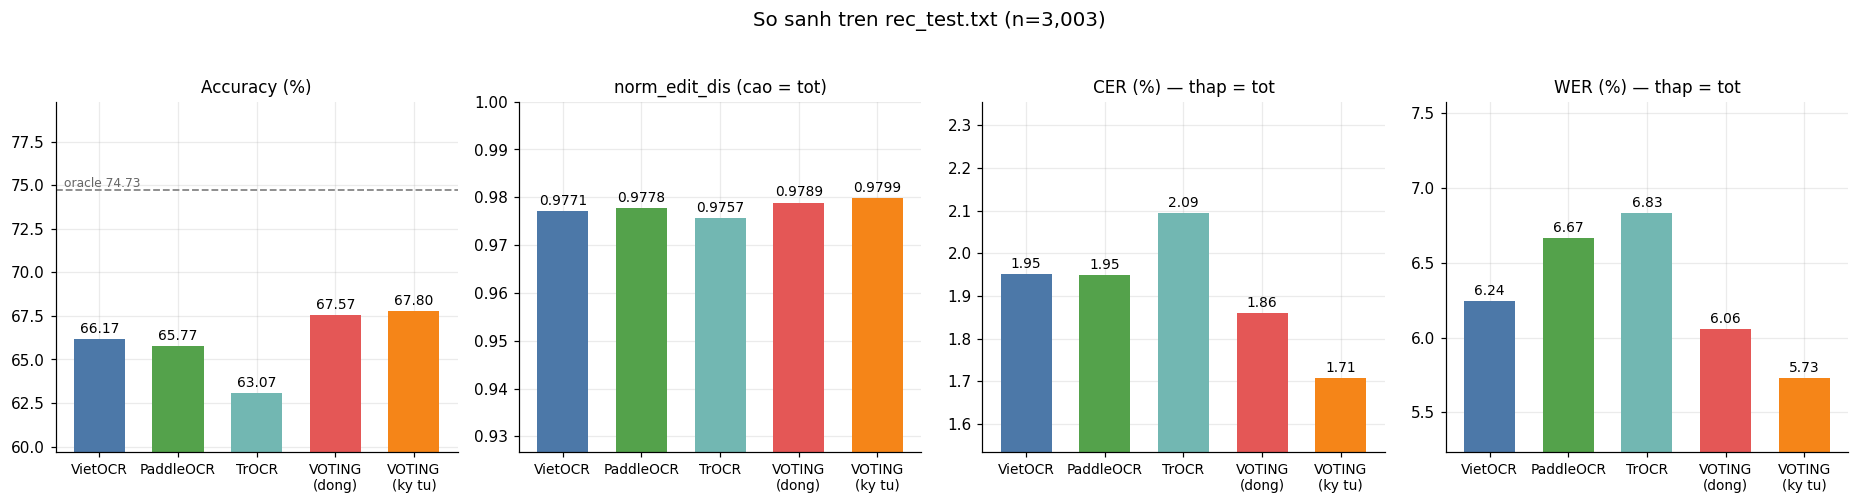

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.axisbelow": True,
                     "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})

PAL = ["#4C78A8", "#54A24B", "#72B7B2", "#E45756", "#F58518"]
CLR = {n: PAL[i % len(PAL)] for i, n in enumerate(ENTRIES)}
SHORT = [n.replace(" (", "\n(") for n in ENTRIES]
ORACLE_ACC = len(oracle) / len(test_rows) * 100

fig, ax = plt.subplots(1, 4, figsize=(17, 4.4))
panels = [("acc", "Accuracy (%)", 100, "%.2f", 100.0, True),
          ("norm_edit_dis", "norm_edit_dis (cao = tot)", 1, "%.4f", 1.0, False),
          ("cer", "CER (%) — thap = tot", 100, "%.2f", 100.0, False),
          ("wer", "WER (%) — thap = tot", 100, "%.2f", 100.0, False)]

for a, (key, title, mul, fmt, cap, up) in zip(ax, panels):
    vals = [metrics[n][key] * mul for n in ENTRIES]
    b = a.bar(SHORT, vals, color=[CLR[n] for n in ENTRIES], width=.65)
    a.bar_label(b, fmt=fmt, padding=2, fontsize=9)
    lo, hi = min(vals), max(vals)
    pad = max((hi - lo) * .45, hi * .05)
    if up:
        hi = max(hi, ORACLE_ACC)
        a.axhline(ORACLE_ACC, ls="--", lw=1.2, c="#888")
        a.text(-.45, ORACLE_ACC, f"oracle {ORACLE_ACC:.2f}", va="bottom",
               ha="left", fontsize=8, color="#666")
    a.set_ylim(max(0, lo - pad), min(hi + pad * 1.5, cap))
    a.set_title(title, fontsize=11)
    a.tick_params(axis="x", labelsize=9)

fig.suptitle(f"So sanh tren rec_test.txt (n={len(test_rows):,})", y=1.03, fontsize=13)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "fig_metrics.png", dpi=140, bbox_inches="tight")
plt.show()

## 10. Giải phẫu lá phiếu

Mỗi dòng test rơi vào một trong ba tình huống. Cột phải cho biết mức độ đáng tin của
từng tình huống — đây là con số nói lên hợp phiếu có ý nghĩa hay không.

,tinh huong,so dong,ty le_%,dong dung,do chinh xac_%
0,dong thuan 3/3,1887,62.84,1635,86.65
1,dong thuan 2/3,713,23.74,342,47.97
2,khong model nao trung nhau,403,13.42,52,12.90


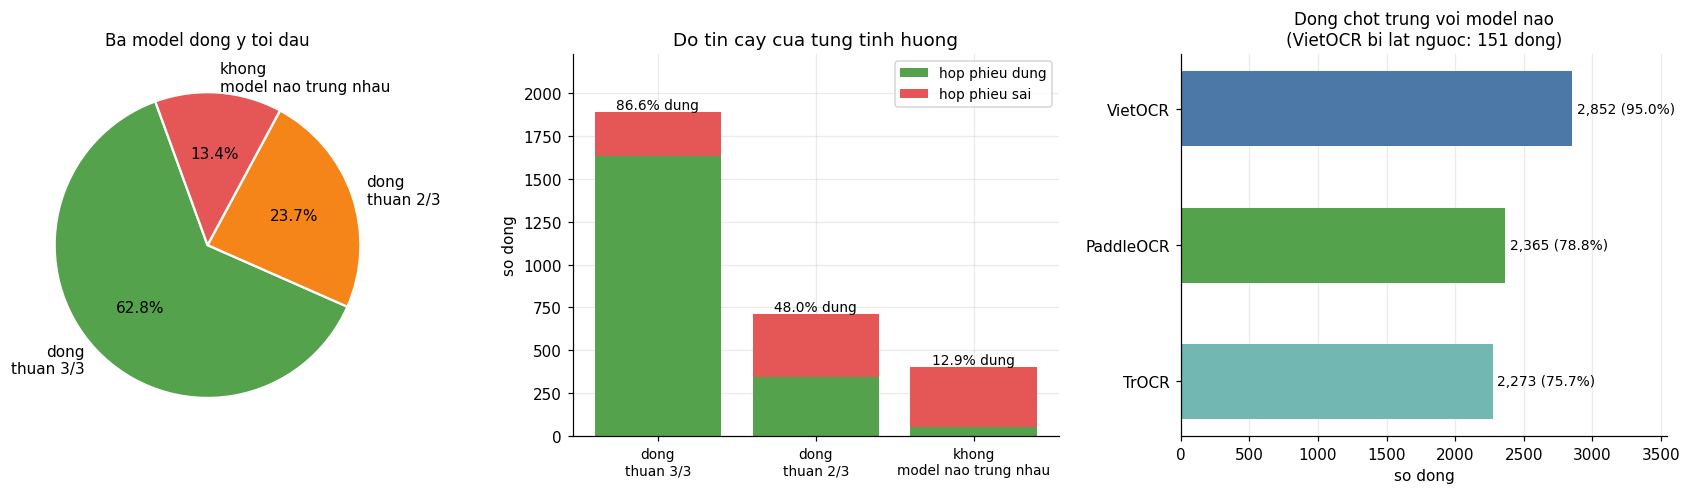

In [13]:
sit_counts = Counter(vote_why.values())
sit_labels = sorted(sit_counts,
                    key=lambda s: (1, 0) if "/" not in s else (0, -int(s.split("/")[0][-1])))
sit_rels = {s: [rel for rel, _ in test_rows if vote_why[rel] == s] for s in sit_labels}
sit_ok = {s: sum(1 for rel in sit_rels[s] if rel in correct[LINE]) for s in sit_labels}

sit_df = pd.DataFrame([{"tinh huong": s, "so dong": len(sit_rels[s]),
                        "ty le_%": round(len(sit_rels[s]) / len(test_rows) * 100, 2),
                        "dong dung": sit_ok[s],
                        "do chinh xac_%": round(sit_ok[s] / max(len(sit_rels[s]), 1) * 100, 2)}
                       for s in sit_labels])
display(sit_df)
sit_df.to_csv(RESULTS_DIR / "vote_situations.csv", index=False)

src_counts = Counter(vote_src.values())
match_final = {n: sum(1 for rel, _ in test_rows
                      if metric_text(preds[n].get(rel, "")) == metric_text(vote_pred[rel]))
               for n in order}
overruled = sum(1 for rel, _ in test_rows
                if metric_text(preds[order[0]].get(rel, "")) != metric_text(vote_pred[rel]))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
sit_colors = ["#54A24B", "#F58518", "#E45756"][:len(sit_labels)]

ax[0].pie([len(sit_rels[s]) for s in sit_labels],
          labels=[s.replace(" ", "\n", 1) for s in sit_labels],
          colors=sit_colors, autopct="%1.1f%%", startangle=110,
          wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax[0].set_title("Ba model dong y toi dau", fontsize=11)

x = np.arange(len(sit_labels))
ok = np.array([sit_ok[s] for s in sit_labels])
tot = np.array([len(sit_rels[s]) for s in sit_labels])
ax[1].bar(x, ok, color="#54A24B", label="hop phieu dung")
ax[1].bar(x, tot - ok, bottom=ok, color="#E45756", label="hop phieu sai")
for i, (o, t) in enumerate(zip(ok, tot)):
    ax[1].text(i, t, f"{o/max(t,1)*100:.1f}% dung", ha="center", va="bottom", fontsize=9)
ax[1].set_xticks(x)
ax[1].set_xticklabels([s.replace(" ", "\n", 1) for s in sit_labels], fontsize=9)
ax[1].set_ylim(0, tot.max() * 1.18)
ax[1].set(title="Do tin cay cua tung tinh huong", ylabel="so dong")
ax[1].legend(fontsize=9)

names = sorted(match_final, key=match_final.get)
vals = [match_final[n] for n in names]
b = ax[2].barh(names, vals, color=[CLR.get(n, "#999") for n in names], height=.55)
ax[2].bar_label(b, labels=[f"{v:,} ({v/len(test_rows)*100:.1f}%)" for v in vals],
                padding=3, fontsize=9)
ax[2].set_xlim(0, len(test_rows) * 1.18)
ax[2].set(xlabel="so dong")
ax[2].set_title(f"Dong chot trung voi model nao\n({order[0]} bi lat nguoc: {overruled:,} dong)",
                fontsize=11)
ax[2].grid(axis="y", visible=False)

plt.tight_layout()
fig.savefig(RESULTS_DIR / "fig_vote_anatomy.png", dpi=140, bbox_inches="tight")
plt.show()

## 11. Ba model bổ sung cho nhau tới đâu

`ORACLE` là số dòng có ít nhất một model đọc đúng — trần lý thuyết của mọi cách hợp phiếu.
Khoảng cách giữa oracle và model tốt nhất chính là phần mà hợp phiếu đang cố giành lấy.

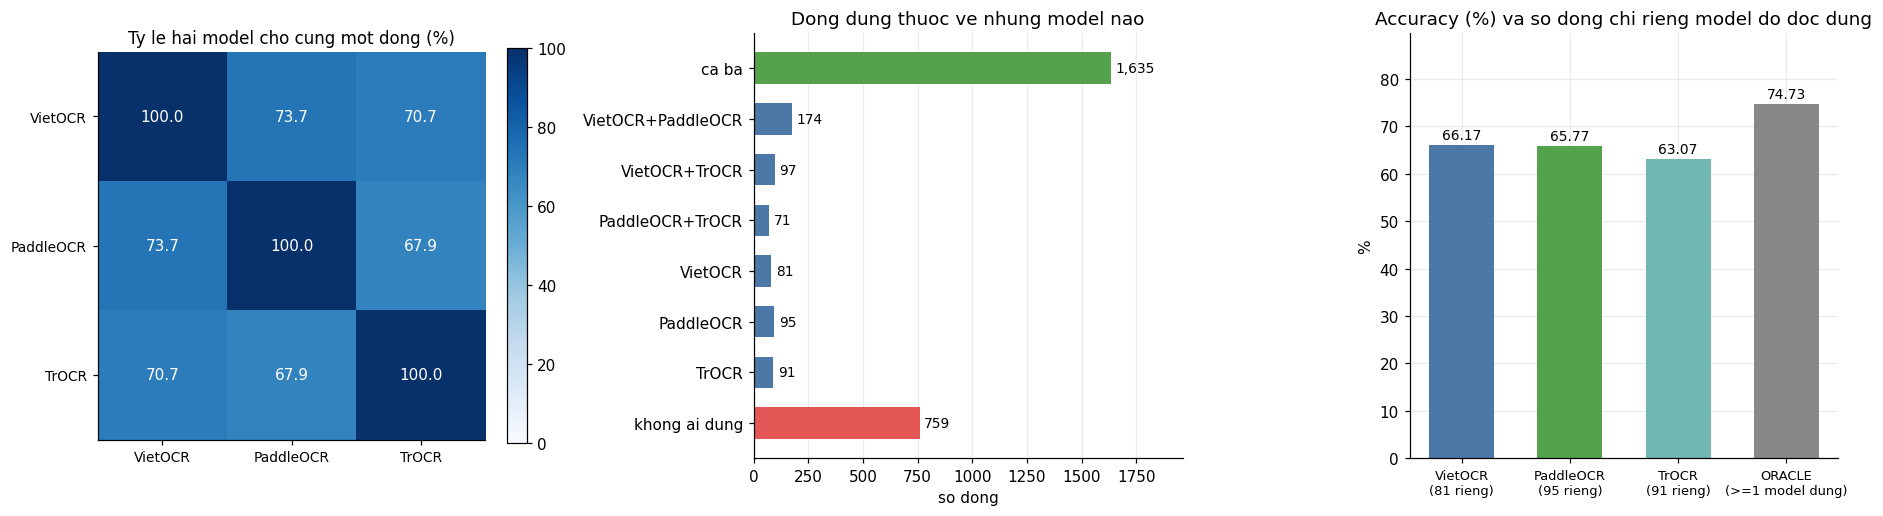

In [14]:
pairs = list(itertools.combinations(order, 2))
agree = {(a, b): sum(1 for rel, _ in test_rows
                     if metric_text(preds[a].get(rel, "")) == metric_text(preds[b].get(rel, "")))
         / len(test_rows) * 100 for a, b in pairs}

regions = []
for r in range(len(order), 0, -1):
    for combo in itertools.combinations(order, r):
        rest = [correct[n] for n in order if n not in combo]
        s = set.intersection(*[correct[n] for n in combo]) - set().union(*rest, set())
        regions.append(("+".join(combo) if r < len(order) else "ca ba", len(s)))
regions.append(("khong ai dung", len(test_rows) - len(oracle)))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

M = np.full((len(order), len(order)), np.nan)
for i, a in enumerate(order):
    for j, b in enumerate(order):
        if i == j:
            M[i, j] = 100.0
        else:
            M[i, j] = agree.get((a, b), agree.get((b, a)))
im = ax[0].imshow(M, cmap="Blues", vmin=0, vmax=100)
ax[0].set_xticks(range(len(order)), order, fontsize=9)
ax[0].set_yticks(range(len(order)), order, fontsize=9)
for i in range(len(order)):
    for j in range(len(order)):
        ax[0].text(j, i, f"{M[i,j]:.1f}", ha="center", va="center", fontsize=10,
                   color="white" if M[i, j] > 55 else "#333")
ax[0].set_title("Ty le hai model cho cung mot dong (%)", fontsize=11)
ax[0].grid(False)
fig.colorbar(im, ax=ax[0], fraction=.046)

labs = [r[0] for r in regions]
vals = [r[1] for r in regions]
cols = ["#54A24B" if "ca ba" in l else "#E45756" if "khong" in l else "#4C78A8" for l in labs]
b = ax[1].barh(labs[::-1], vals[::-1], color=cols[::-1], height=.62)
ax[1].bar_label(b, labels=[f"{v:,}" for v in vals[::-1]], padding=3, fontsize=9)
ax[1].set_xlim(0, max(vals) * 1.2)
ax[1].set(title="Dong dung thuoc ve nhung model nao", xlabel="so dong")
ax[1].grid(axis="y", visible=False)

only = {n: len(correct[n] - set().union(*[correct[m] for m in order if m != n], set()))
        for n in order}
bars = [metrics[n]["acc"] * 100 for n in order] + [ORACLE_ACC]
lbls = [f"{n}\n({only[n]:,} rieng)" for n in order] + ["ORACLE\n(>=1 model dung)"]
b = ax[2].bar(lbls, bars, color=[CLR[n] for n in order] + ["#888"], width=.6)
ax[2].bar_label(b, fmt="%.2f", padding=2, fontsize=9)
ax[2].set_ylim(0, max(bars) * 1.2)
ax[2].tick_params(axis="x", labelsize=8.5)
ax[2].set(title="Accuracy (%) va so dong chi rieng model do doc dung", ylabel="%")

plt.tight_layout()
fig.savefig(RESULTS_DIR / "fig_complementarity.png", dpi=140, bbox_inches="tight")
plt.show()

pd.DataFrame(regions, columns=["nhom model doc dung", "so dong"]).to_csv(
    RESULTS_DIR / "venn_regions.csv", index=False)

## 12. Hợp phiếu được gì, mất gì

Cột trái đếm trực tiếp: bao nhiêu dòng hợp phiếu sửa được cho model tốt nhất, bao nhiêu dòng
nó làm hỏng. Cột phải phân bố số ký tự sai trên mỗi dòng — nhìn được cả những dòng chưa đúng
hẳn nhưng đã sai ít đi.

,hop phieu,so voi,sua duoc,lam hong,loi rong
0,VOTING (dong),VietOCR,71,29,42
1,VOTING (dong),PaddleOCR,149,95,54
2,VOTING (dong),TrOCR,226,91,135
3,VOTING (ky tu),VietOCR,100,51,49
4,VOTING (ky tu),PaddleOCR,144,83,61
5,VOTING (ky tu),TrOCR,224,82,142


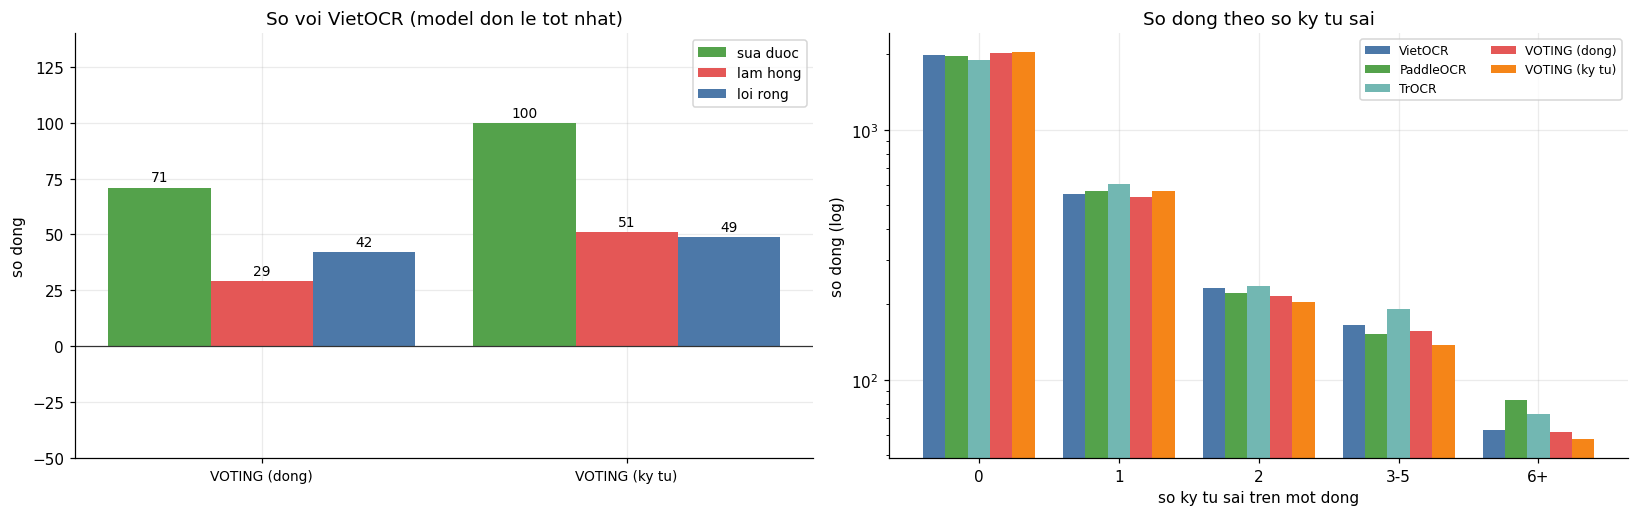

In [15]:
delta = []
for v in (LINE, CHAR):
    for ref in order:
        fixed = len(correct[v] - correct[ref])
        broke = len(correct[ref] - correct[v])
        delta.append({"hop phieu": v, "so voi": ref, "sua duoc": fixed,
                      "lam hong": broke, "loi rong": fixed - broke})
delta_df = pd.DataFrame(delta)
display(delta_df)
delta_df.to_csv(RESULTS_DIR / "voting_delta.csv", index=False)

BUCKETS = ["0", "1", "2", "3-5", "6+"]


def bucket(d):
    return "0" if d == 0 else "1" if d == 1 else "2" if d == 2 else "3-5" if d <= 5 else "6+"


dist = {}
for n in ENTRIES:
    c = Counter(bucket(Levenshtein.distance(metric_text(allpred[n].get(rel, "")), metric_text(gt)))
                for rel, gt in test_rows)
    dist[n] = [c.get(b, 0) for b in BUCKETS]

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))

sub = delta_df[delta_df["so voi"] == best]
x = np.arange(len(sub))
w = .28
for k, (col, c) in enumerate([("sua duoc", "#54A24B"), ("lam hong", "#E45756"),
                              ("loi rong", "#4C78A8")]):
    b = ax[0].bar(x + (k - 1) * w, sub[col], w, label=col, color=c)
    ax[0].bar_label(b, fmt="%d", padding=2, fontsize=9)
ax[0].axhline(0, c="#333", lw=.8)
vmax = max(1, int(sub[["sua duoc", "lam hong"]].to_numpy().max()))
ax[0].set_ylim(-vmax * .5, vmax * 1.4)
ax[0].set_xticks(x, sub["hop phieu"], fontsize=9)
ax[0].set(title=f"So voi {best} (model don le tot nhat)", ylabel="so dong")
ax[0].legend(fontsize=9)

x = np.arange(len(BUCKETS))
w = .8 / len(ENTRIES)
for k, n in enumerate(ENTRIES):
    ax[1].bar(x + (k - (len(ENTRIES) - 1) / 2) * w, dist[n], w, label=n, color=CLR[n])
ax[1].set_xticks(x, BUCKETS)
ax[1].set_yscale("log")
ax[1].set(title="So dong theo so ky tu sai", xlabel="so ky tu sai tren mot dong",
          ylabel="so dong (log)")
ax[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
fig.savefig(RESULTS_DIR / "fig_voting_gain.png", dpi=140, bbox_inches="tight")
plt.show()

pd.DataFrame(dist, index=BUCKETS).T.to_csv(RESULTS_DIR / "error_length_dist.csv")

## 13. Phân tích lỗi

20 dòng hợp phiếu đọc sai, xếp theo ba loại của đề bài.

,anh,label,du doan,loai loi
0,test/datviettroinam_page_278_crop_14.jpg,Chim cũng tiêu biểu cho người anh hùng chưa th...,Chim cũng tiệu biểu cho người anh hùng chưa th...,sai chu cai
1,test/quanthukhaobien__page_373_crop_8.jpg,Quách Nguyên Chấn(). Quả thực thời bấy giờ khô...,Quách Nguyên Chấn(5). Quả thực thời bấy giờ kh...,sai chu cai
2,test/tutrithonggiam6__page_187_crop_9.jpg,6. Núi Chung Nam) sạt lở.,6. Núi Chung Nam(1) sạt lở.,sai chu cai
3,test/minhmenhchinhyeutap2__page_108_crop_4.jpg,"Ảnh nhiều, nhân đi đồn trú các nơi lam chướng ...","lính nhiều, nhân đi đồn trú các nơi lam chướng...",sai chu cai
4,test/sv_1498_crop_36.jpg,quê nghi ngơi.,quê nghỉ ngơi.,sai dau thanh
5,test/sv_1379_crop_34.jpg,"Hoàng Văn Nguyệt, Nguyễn Văn Trị, Vũ Văn Loan,...","Hoàng Văn Nguyệt, Nguyễn Văn Trị, Vũ Văn Loan,...",sai chu cai
6,test/giadaotruyenthongbao_page_049_crop_3.jpg,2 đồng,2dong,sai chu cai
7,test/letrieulichkhoatiensitap3__page_023_crop_...,"thân, bọn","than, bon",sai chu cai
8,test/daivietlichtrieudangkhoaluc1__page_284_cr...,- 289,289,sai chu cai
9,test/MinhMenhchinhyeutap6ocr__page_380_crop_21...,1971. 22 + XXVIII trang. Giá : 16000.,1971. 22 4 XXVIII trang. Giá: 1600.,sai chu cai


,loai,so dong,ty le_%
0,sai dau thanh,230,22.2
1,sai chu cai,798,77.2
2,lap ky tu,6,0.6


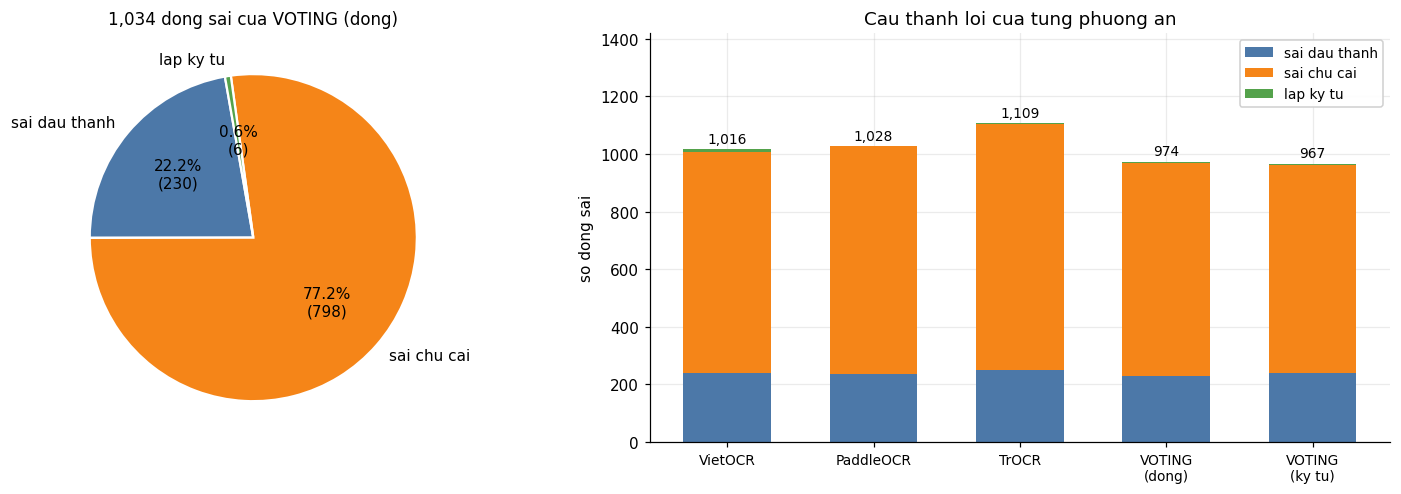

  label : Chim cũng tiêu biểu cho người anh hùng chưa thỏa chí :
  du doan: Chim cũng tiệu biểu cho người anh hùng chưa thỏa chí:   [sai chu cai]

  label : Quách Nguyên Chấn(). Quả thực thời bấy giờ không có
  du doan: Quách Nguyên Chấn(5). Quả thực thời bấy giờ không có   [sai chu cai]

  label : 6. Núi Chung Nam) sạt lở.
  du doan: 6. Núi Chung Nam(1) sạt lở.   [sai chu cai]

  label : Ảnh nhiều, nhân đi đồn trú các nơi lam chướng nên đền bị
  du doan: lính nhiều, nhân đi đồn trú các nơi lam chướng nên đều bị   [sai chu cai]

  label : quê nghi ngơi.
  du doan: quê nghỉ ngơi.   [sai dau thanh]

  label : Hoàng Văn Nguyệt, Nguyễn Văn Trị, Vũ Văn Loan, Nguyễn Vân Thịnh,
  du doan: Hoàng Văn Nguyệt, Nguyễn Văn Trị, Vũ Văn Loan, Nguyễn Văn Thịnh,   [sai chu cai]

  label : 2 đồng
  du doan: 2dong   [sai chu cai]

  label : thân, bọn
  du doan: than, bon   [sai chu cai]

  label : - 289
  du doan: 289   [sai chu cai]

  label : 1971. 22 + XXVIII trang. Giá : 16000.
  du doan: 1971. 22 4 

In [16]:
wrong = [r for r in vote_recs
         if unicodedata.normalize("NFC", r["gt"]) != unicodedata.normalize("NFC", r["pred"])]
for r in wrong:
    r["loai"] = classify(r["gt"], r["pred"])
sample = random.Random(SEED).sample(wrong, min(20, len(wrong)))

err = pd.DataFrame([{"anh": r["image"], "label": r["gt"], "du doan": r["pred"],
                     "loai loi": r["loai"]} for r in sample])
display(err)
err.to_csv(RESULTS_DIR / "error_samples.csv", index=False)

TYPES = ["sai dau thanh", "sai chu cai", "lap ky tu"]
cnt_all = Counter(r["loai"] for r in wrong)
by_model = {n: Counter(classify(GT[rel], allpred[n].get(rel, ""))
                       for rel, _ in test_rows if rel not in correct[n]) for n in ENTRIES}

dist_df = pd.DataFrame([{"loai": t, "so dong": cnt_all.get(t, 0),
                         "ty le_%": round(cnt_all.get(t, 0) / max(len(wrong), 1) * 100, 1)}
                        for t in TYPES])
display(dist_df)
dist_df.to_csv(RESULTS_DIR / "error_types.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
tcol = ["#4C78A8", "#F58518", "#54A24B"]

ax[0].pie([cnt_all.get(t, 0) for t in TYPES], labels=TYPES, colors=tcol,
          autopct=lambda p: f"{p:.1f}%\n({int(round(p*len(wrong)/100)):,})", startangle=100,
          wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax[0].set_title(f"{len(wrong):,} dong sai cua {LINE}", fontsize=11)

x = np.arange(len(ENTRIES))
bottom = np.zeros(len(ENTRIES))
for t, c in zip(TYPES, tcol):
    v = np.array([by_model[n].get(t, 0) for n in ENTRIES])
    ax[1].bar(x, v, .6, bottom=bottom, label=t, color=c)
    bottom += v
ax[1].bar_label(ax[1].containers[-1], labels=[f"{int(v):,}" for v in bottom], padding=2,
                fontsize=9)
ax[1].set_xticks(x, SHORT, fontsize=9)
ax[1].set_ylim(0, bottom.max() * 1.28)
ax[1].set(title="Cau thanh loi cua tung phuong an", ylabel="so dong sai")
ax[1].legend(fontsize=9, loc="upper right", framealpha=.92)

plt.tight_layout()
fig.savefig(RESULTS_DIR / "fig_error_types.png", dpi=140, bbox_inches="tight")
plt.show()

for r in sample[:10]:
    print(f"  label : {r['gt'][:95]}")
    print(f"  du doan: {r['pred'][:95]}   [{r['loai']}]\n")

## 14. Đóng gói

In [17]:
summary = {
    "test_set": str(TEST_FILE), "n": len(test_rows),
    "ignore_space": IGNORE_SPACE, "seed": SEED,
    "vote_rule": f"da so; hoa thi theo {order[0]}",
    "models": {n: {k: round(metrics[n][k], 4) for k in ("acc", "norm_edit_dis", "cer", "wer")}
               for n in order},
    "inference_seconds": {n: round(seconds.get(n, 0), 1) for n in order},
    "voting_line": {k: round(vote_metric[k], 4) for k in ("acc", "norm_edit_dis", "cer", "wer")},
    "voting_char": {k: round(char_metric[k], 4) for k in ("acc", "norm_edit_dis", "cer", "wer")},
    "oracle_acc": round(len(oracle) / len(test_rows), 4),
    "vote_situations": {s: len(sit_rels[s]) for s in sit_labels},
    "vote_situation_accuracy": {s: round(sit_ok[s] / max(len(sit_rels[s]), 1), 4)
                                for s in sit_labels},
    "vote_decided_by": dict(src_counts),
    "final_matches_model": match_final,
    "priority_overruled": overruled,
    "venn_regions": dict(regions),
    "error_types_voting_line": dict(cnt_all),
    "total_seconds": round(time.time() - SESSION_START, 1),
}
(RESULTS_DIR / "metrics_voting.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(summary, ensure_ascii=False, indent=2))

print(f"\n{RESULTS_DIR}")
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name:<32}{f.stat().st_size/1024:>9.1f} KB")

{
  "test_set": "/kaggle/input/datasets/quachthanhhmd/dack-nlp/DACK/data/vi_rec_100k/vi_rec_100k/rec_test.txt",
  "n": 3003,
  "ignore_space": true,
  "seed": 2026,
  "vote_rule": "da so; hoa thi theo VietOCR",
  "models": {
    "VietOCR": {
      "acc": 0.6617,
      "norm_edit_dis": 0.9771,
      "cer": 0.0195,
      "wer": 0.0624
    },
    "PaddleOCR": {
      "acc": 0.6577,
      "norm_edit_dis": 0.9778,
      "cer": 0.0195,
      "wer": 0.0667
    },
    "TrOCR": {
      "acc": 0.6307,
      "norm_edit_dis": 0.9757,
      "cer": 0.0209,
      "wer": 0.0683
    }
  },
  "inference_seconds": {
    "VietOCR": 373.9,
    "PaddleOCR": 175.5,
    "TrOCR": 145.7
  },
  "voting_line": {
    "acc": 0.6757,
    "norm_edit_dis": 0.9789,
    "cer": 0.0186,
    "wer": 0.0606
  },
  "voting_char": {
    "acc": 0.678,
    "norm_edit_dis": 0.9799,
    "cer": 0.0171,
    "wer": 0.0573
  },
  "oracle_acc": 0.7473,
  "vote_situations": {
    "dong thuan 3/3": 1887,
    "dong thuan 2/3": 713,
    "k